# Eksplorativna analiza podataka – Online Poker Games

## Cilj analize

Cilj ove analize je razumevanje strukture skupa podataka koji sadrži informacije o online poker partijama. 

Fokus je na:
- analizi akcija igrača (bet, raise, fold...)
- veličini uloga (bet)
- ishodu ruke (result, balance)
- kontekstu igre (position, stack, pot)

Ova analiza predstavlja osnovu za:
- definisanje blefa
- feature engineering
- izgradnju klasifikacionog modela

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/blef_dataset.csv")


df.head()

,buyin,tourn_id,table,hand_id,date,time,table_size,level,playing,seat,name,stack,position,action_pre,action_flop,action_turn,action_river,all_in,cards,board_flop,board_turn,board_river,combination,pot_pre,pot_flop,pot_turn,pot_river,ante,blinds,bet_pre,bet_flop,bet_turn,bet_river,result,balance
0,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,1,fa538846,500,BTN,folds,x,x,x,False,8d Qh,0,0,0,NaN,30,30,30,30,0,0,0,0,0,0,gave up,0
1,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,2,676c5599,500,SB,folds,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,10,10,0,0,0,gave up,-10
2,$0.92+$0.08,2929450288,1,215051507105,2020-06-07,18:15:09,3,1,3,3,7055f691,500,BB,x,x,x,x,False,--,0,0,0,NaN,30,30,30,30,0,20,20,0,0,0,took chips,10
3,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,1,fa538846,500,BB,raises,bets-doesn't,x,x,False,Ks 4s,Ad Kh 4c,0,0,NaN,120,180,180,180,0,20,60,60,0,0,took chips,60
4,$0.92+$0.08,2929450288,1,215051520234,2020-06-07,18:15:23,3,1,3,2,676c5599,490,BTN,folds,x,x,x,False,--,Ad Kh 4c,0,0,NaN,120,180,180,180,0,0,0,0,0,0,gave up,0


## Osnovne informacije o datasetu

Analiziramo strukturu skupa podataka, tipove atributa i osnovne statistike.

Jedan red u datasetu predstavlja jednu poker ruku za jednog igrača.

Dataset sadrži veliki broj atributa koji opisuju:

- karakteristike igrača (pozicija, stack)
- tok igre (akcije po fazama: preflop, flop, turn, river)
- finansijske vrednosti (betovi, pot)
- ishod ruke (result, balance)

Posebno su značajne kolone koje opisuju akcije igrača i veličinu uloga, jer su direktno povezane sa analizom blefa.

---



In [2]:
df.columns.tolist()

['buyin',
 'tourn_id',
 'table',
 'hand_id',
 'date',
 'time',
 'table_size',
 'level',
 'playing',
 'seat',
 'name',
 'stack',
 'position',
 'action_pre',
 'action_flop',
 'action_turn',
 'action_river',
 'all_in',
 'cards',
 'board_flop',
 'board_turn',
 'board_river',
 'combination',
 'pot_pre',
 'pot_flop',
 'pot_turn',
 'pot_river',
 'ante',
 'blinds',
 'bet_pre',
 'bet_flop',
 'bet_turn',
 'bet_river',
 'result',
 'balance']

## Provera kvaliteta podataka

Proveravamo:
- nedostajuće vrednosti
- duplikate
- distribuciju kategorijskih vrednosti

In [3]:
df.isnull().sum().sort_values(ascending=False)


combination     84175
tourn_id            0
buyin               0
table               0
hand_id             0
time                0
date                0
level               0
playing             0
seat                0
table_size          0
stack               0
position            0
action_pre          0
action_flop         0
action_turn         0
action_river        0
all_in              0
name                0
cards               0
board_flop          0
board_turn          0
board_river         0
pot_pre             0
pot_flop            0
pot_turn            0
pot_river           0
ante                0
blinds              0
bet_pre             0
bet_flop            0
bet_turn            0
bet_river           0
result              0
balance             0
dtype: int64

Kolona `combination` sadrži veliki broj nedostajućih vrednosti, što je očekivano jer se kombinacija karata vidi samo u slučajevima kada dođe do showdown-a.


In [4]:
df.duplicated().sum()

np.int64(0)

Nisu pronađeni duplikati u datasetu.

In [5]:
for col in ["action_pre", "action_flop", "action_turn", "action_river", "result", "position"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


action_pre
action_pre
folds                        32900
calls                        20717
raises                       12097
checks                       11837
doesn't                       7647
raises-doesn't                7447
calls-calls                   2722
calls-folds                   2640
x                             2044
raises-calls                  1541
raises-folds                   514
calls-raises                   187
raises-raises                  180
calls-doesn't                   34
calls-raises-doesn't            26
calls-raises-calls              19
raises-raises-calls             18
raises-raises-doesn't           13
raises-shows                     7
shows                            5
raises-raises-raises             4
calls-calls-calls                4
calls-raises-raises              3
raises-calls-calls               3
calls-calls-folds                2
calls-raises-raises-calls        1
calls-calls-raises               1
raises-raises-folds             

Akcije igrača su predstavljene kategorijskim vrednostima i deluju konzistentno.

## Pretprocesiranje podataka

Potrebno je izvršiti osnovnu pripremu podataka kako bi analiza bila pouzdana i kako bi se kasnije ovaj skup mogao povezati sa modelom za procenu jačine ruke.

Pošto je cilj projekta detekcija blefa, a blef zavisi i od ponašanja igrača i od objektivne jačine ruke, u ovoj fazi pretprocesiranja fokus je na:

- standardizaciji tekstualnih vrednosti
- konverziji datuma i vremena
- parsiranju privatnih i zajedničkih karata
- formiranju pomoćnih atributa koji će biti korisni u daljoj analizi i kasnijoj proceni jačine ruke

### Standardizacija tekstualnih vrednosti

In [6]:
text_cols = [
    "position",
    "action_pre",
    "action_flop",
    "action_turn",
    "action_river",
    "result",
    "cards",
    "board_flop",
    "board_turn",
    "board_river",
    "combination"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

### Konverzija datuma i vremena

In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce").dt.time

df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"].astype(str),
    errors="coerce"
)

### Parsiranje karata

Karte su parsirane iz string formata u listu kako bi se omogućila dalja analiza.

- `hole_cards` predstavljaju privatne karte igrača
- `flop_cards`, `turn_card` i `river_card` predstavljaju zajedničke karte

Vrednosti poput "0" ili "--" označavaju da karte nisu dostupne.

In [8]:
def parse_cards(value):
    value = str(value).strip().lower()
    
    if value in ["0", "--", "nan", "none"]:
        return []
    
    return value.split()

# privatne karte
df["hole_cards"] = df["cards"].apply(parse_cards)

# zajedničke karte
df["flop_cards"] = df["board_flop"].apply(parse_cards)
df["turn_card"] = df["board_turn"].apply(parse_cards)
df["river_card"] = df["board_river"].apply(parse_cards)

### Formiranje pomoćnih atributa

In [9]:
df["board_flop_full"] = df["flop_cards"]
df["board_turn_full"] = df["flop_cards"] + df["turn_card"]
df["board_river_full"] = df["flop_cards"] + df["turn_card"] + df["river_card"]

Formirani su atributi koji predstavljaju stanje table u svakoj fazi igre:

- flop
- turn
- river

Ovo je važno jer će se upravo ovi podaci koristiti kao ulaz za model koji procenjuje jačinu ruke.

In [10]:
df["num_hole"] = df["hole_cards"].apply(len)
df["num_flop"] = df["flop_cards"].apply(len)
df["num_turn"] = df["turn_card"].apply(len)
df["num_river"] = df["river_card"].apply(len)

df["has_full_hand"] = (df["num_hole"] == 2)
df["has_flop"] = (df["num_flop"] == 3)
df["has_turn"] = (df["num_turn"] == 1)
df["has_river"] = (df["num_river"] == 1)

Kreirani su pomoćni atributi koji pokazuju dostupnost podataka:

- da li su poznate privatne karte
- da li su dostupne zajedničke karte po fazama igre

Ovo je važno za procenu u kojim slučajevima je moguće odrediti jačinu ruke.

In [11]:
print("Ukupno redova:", len(df))
print("Ima hole cards:", (df["has_full_hand"]).sum())
print("Ima flop:", (df["has_flop"]).sum())
print("Ima turn:", (df["has_turn"]).sum())
print("Ima river:", (df["has_river"]).sum())

Ukupno redova: 102615
Ima hole cards: 54294
Ima flop: 57271
Ima turn: 39351
Ima river: 32496


Na osnovu ovih rezultata može se proceniti u kom procentu slučajeva je moguće rekonstruisati ruku igrača i primeniti model za procenu jačine ruke.

Ovaj korak je ključan za povezivanje dataset-a sa modelom razvijenim u prethodnoj fazi projekta.

## Povezivanje novog dataset-a sa modelom za procenu jačine ruke

U ovom delu koristi se model istreniran na skupu `poker_dataset.csv` za procenu jačine ruke u novom skupu podataka.

Pristup je sledeći:

1. Na skupu `poker_dataset.csv` trenira se model za klasifikaciju jačine ruke.
2. U novom skupu se iz privatnih i zajedničkih karata rekonstruišu kombinacije na flopu i turnu.
3. Na osnovu tih informacija formiraju se ulazni atributi istog tipa kao u prethodnom modelu.
4. Model zatim predviđa kategoriju jačine ruke za redove u kojima su privatne karte poznate.

Na ovaj način se novi skup podataka povezuje sa prethodno razvijenim delom projekta.

In [12]:
import joblib

model = joblib.load("../model/hand_strength_model.pkl")
model_columns = joblib.load("../model/hand_strength_model_columns.pkl")


In [13]:
import sys
from pathlib import Path

src_path = (Path.cwd() / "../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from blef import best_hand_class, max_card_from_hole, same_suit_from_hole

df["result1_class"] = df.apply(
    lambda row: best_hand_class(row["hole_cards"] + row["board_flop_full"])
    if isinstance(row["hole_cards"], list) and isinstance(row["board_flop_full"], list) and len(row["hole_cards"]) == 2 and len(row["board_flop_full"]) == 3
    else np.nan,
    axis=1
)

df["result2_class"] = df.apply(
    lambda row: best_hand_class(row["hole_cards"] + row["board_turn_full"])
    if isinstance(row["hole_cards"], list) and isinstance(row["board_turn_full"], list) and len(row["hole_cards"]) == 2 and len(row["board_turn_full"]) == 4
    else np.nan,
    axis=1
)

df["max_card"] = df["hole_cards"].apply(
    lambda cards: max_card_from_hole(cards) if isinstance(cards, list) and len(cards) == 2 else np.nan
)

df["same_suit"] = df["hole_cards"].apply(
    lambda cards: same_suit_from_hole(cards) if isinstance(cards, list) and len(cards) == 2 else np.nan
)

In [14]:
df_model = df.dropna(subset=["result1_class", "result2_class", "max_card", "same_suit"]).copy()

X_cat = pd.get_dummies(df_model[["result1_class", "result2_class"]])
X_num = df_model[["max_card", "same_suit"]]

X = pd.concat([X_cat, X_num], axis=1)

for col in model_columns:
    if col not in X.columns:
        X[col] = 0

X = X[model_columns]

In [15]:
df_model["predicted_hand_strength"] = model.predict(X)

In [16]:
if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X)
    probs_df = pd.DataFrame(probs, columns=model.classes_, index=df_model.index)
    probs_df = probs_df.add_prefix("proba_")
    df_model = pd.concat([df_model, probs_df], axis=1)

In [17]:
df["predicted_hand_strength"] = None
df.loc[df_model.index, "predicted_hand_strength"] = df_model["predicted_hand_strength"].astype(str)

In [18]:
for col in probs_df.columns:
    df[col] = np.nan
    df.loc[df_model.index, col] = df_model[col]

### Distribucija jačine ruke

Na sledećem grafiku prikazana je distribucija predviđene jačine ruke.

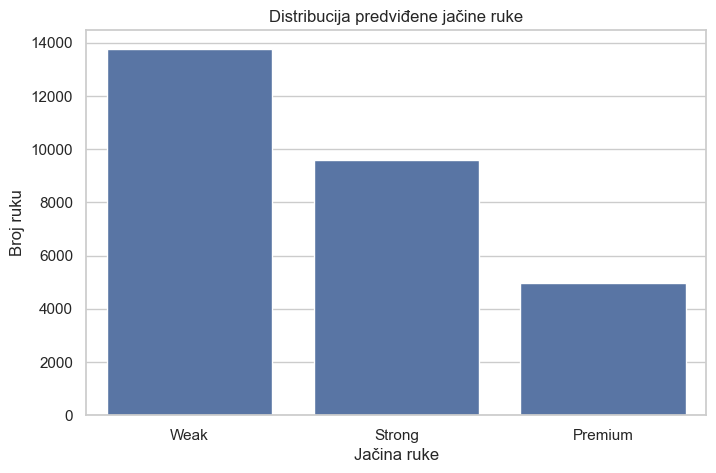

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df[df["predicted_hand_strength"].notna()],
    x="predicted_hand_strength",
    order=df["predicted_hand_strength"].value_counts().index
)
plt.title("Distribucija predviđene jačine ruke")
plt.xlabel("Jačina ruke")
plt.ylabel("Broj ruku")
plt.show()

Najveći broj ruku pripada kategoriji slabih ruku (Weak), što je u skladu sa očekivanjima u pokeru. Jake (Strong) i posebno premium ruke (Premium) javljaju se znatno ređe.

Ovakva distribucija potvrđuje da model daje realistične rezultate i da se ponaša u skladu sa pravilima igre.

### Pokrivenost modela

Model nije mogao da izvrši procenu za sve instance iz skupa podataka, već samo za podskup ruku za koje su dostupni svi potrebni atributi (flop, turn i validne karte).

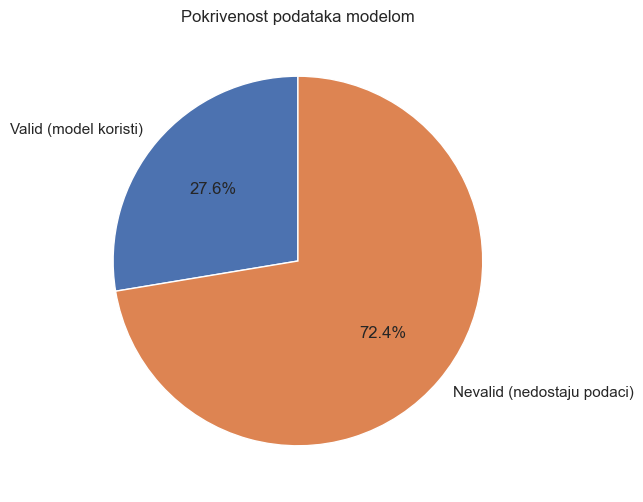

In [20]:
valid = len(df_model)
invalid = len(df) - valid

plt.figure(figsize=(6,6))
plt.pie(
    [valid, invalid],
    labels=["Valid (model koristi)", "Nevalid (nedostaju podaci)"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Pokrivenost podataka modelom")
plt.show()

#### Komentar

Model je primenljiv na deo skupa podataka za koji su dostupni svi potrebni atributi (kompletne informacije o kartama i fazama igre).

Preostali deo podataka nije moguće obraditi jer nedostaju informacije potrebne za rekonstrukciju ruke (npr. flop ili turn).

Iako model ne pokriva ceo skup, broj validnih instanci je dovoljan za dalju analizu i treniranje modela za detekciju blefa.

## Definicija blefa

Pošto dataset ne sadrži eksplicitnu oznaku da li je potez blef, uvedena je heuristička definicija blefa.

U ovom radu blef se definiše kao situacija u kojoj su ispunjeni sledeći uslovi:

- procenjena jačina ruke je slaba (`Weak`)
- igrač je izvršio agresivnu akciju u nekoj fazi igre
- ruka nije završena showdown-om

Agresivna akcija se ovde aproksimira pojavom obrazaca kao što su `bet` ili `raise` u kolonama `action_pre`, `action_flop`, `action_turn` i `action_river`.

Ovakva definicija predstavlja pojednostavljenu, ali praktično upotrebljivu aproksimaciju blefa u skupu podataka.

In [21]:
from blef import is_aggressive_action

df_valid = df[df["predicted_hand_strength"].notna()].copy()

df_valid["aggressive"] = df_valid.apply(is_aggressive_action, axis=1)

df_valid["total_bet"] = (
    df_valid["bet_pre"] +
    df_valid["bet_flop"] +
    df_valid["bet_turn"] +
    df_valid["bet_river"]
)

df_valid["is_bluff"] = (
    (df_valid["predicted_hand_strength"] == "Weak") &
    (df_valid["aggressive"] == 1) &
    (df_valid["total_bet"] > 0) &
    (~df_valid["result"].astype(str).str.lower().str.contains("show", na=False))
)

In [22]:
print(df_valid["is_bluff"].value_counts())
print(df_valid["is_bluff"].value_counts(normalize=True))

is_bluff
False    21668
True      6668
Name: count, dtype: int64
is_bluff
False    0.764681
True     0.235319
Name: proportion, dtype: float64


### Komentar

Na osnovu uvedene heuristike izdvojene su situacije koje mogu predstavljati blef.

Očekivano je da blef situacije čine manji deo svih validnih instanci, jer većina poteza u pokeru nije blef. Istovremeno, prisustvo dovoljnog broja ovakvih primera omogućava dalju analizu i treniranje klasifikacionih modela.

Važno je naglasiti da ovakva definicija blefa nije savršena, već predstavlja aproksimaciju zasnovanu na dostupnim podacima. Ipak, ona je dovoljno informativna za potrebe projekta i omogućava povezivanje procene jačine ruke sa obrascima ponašanja igrača.

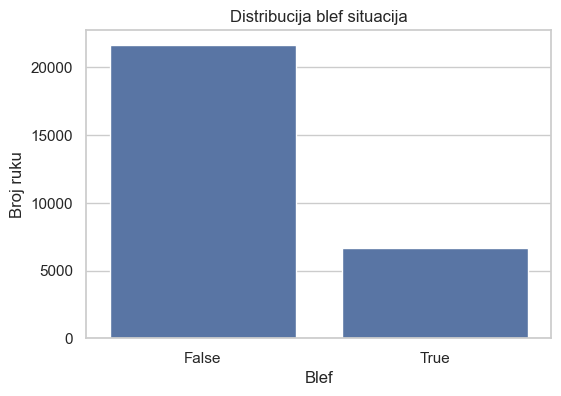

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_valid, x="is_bluff")
plt.title("Distribucija blef situacija")
plt.xlabel("Blef")
plt.ylabel("Broj ruku")
plt.show()

### Distribucija blef situacija

Na grafikonu je prikazana raspodela instanci koje su označene kao blef i onih koje to nisu.

#### Komentar

Rezultati pokazuju da blef situacije predstavljaju manjinski deo skupa podataka, što je u skladu sa očekivanjima. Takva raspodela je karakteristična za realne poker podatke, gde se blef ne javlja u svakoj ruci, već samo u određenim situacijama.

## Trening modela – detekcija blefa

Cilj ove sekcije je da istreniramo više modela klasifikacije koji predviđaju da li je situacija blef (is_bluff), uporedimo njihove performanse i izaberemo najbolji model za dalji rad.

### Priprema podataka za modeliranje

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

feature_cols = [
    c for c in df_valid.columns
    if c not in ["is_bluff", "result", "predicted_hand_strength", "aggressive", "total_bet"]
       and df_valid[c].dtype in ["int64", "float64", "bool"]
]
X = df_valid[feature_cols].copy()
y = df_valid["is_bluff"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

iso = IsolationForest(contamination=0.03, random_state=42)
outlier_pred = iso.fit_predict(X_train)
mask = outlier_pred == 1

X_train_clean = X_train[mask]
y_train = y_train[mask]

print(f"Sklonjeno outlajera iz trening skupa: {len(X_train) - len(X_train_clean)}")

X_train = X_train_clean

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Sklonjeno outlajera iz trening skupa: 681


## Trening i evaluacija modela

### Logistička regresija

Logistic Regression Accuracy: 0.7962244177840508

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.77      0.85      4334
           1       0.54      0.88      0.67      1334

    accuracy                           0.80      5668
   macro avg       0.75      0.82      0.76      5668
weighted avg       0.86      0.80      0.81      5668


Logistic Regression Confusion Matrix:
 [[3342  992]
 [ 163 1171]]


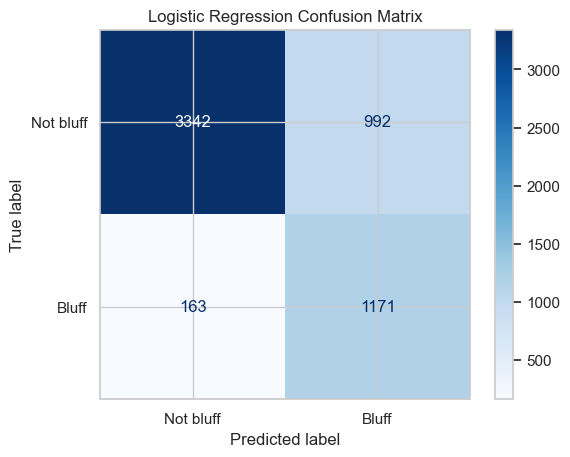

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nLogistic Regression Classification Report:\n",
      classification_report(y_test, y_pred_logreg, zero_division=0))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, display_labels=["Not bluff", "Bluff"], cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Naive Bayes

Naive Bayes Accuracy: 0.7870501058574453

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.80      0.85      4334
           1       0.53      0.73      0.62      1334

    accuracy                           0.79      5668
   macro avg       0.72      0.77      0.74      5668
weighted avg       0.82      0.79      0.80      5668


Naive Bayes Confusion Matrix:
 [[3482  852]
 [ 355  979]]


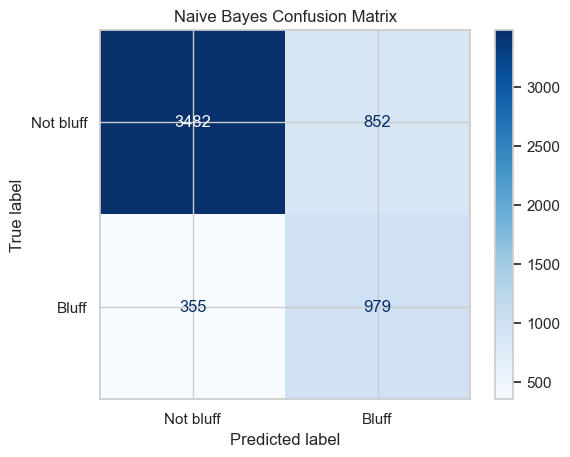

In [28]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n",
      classification_report(y_test, y_pred_nb, zero_division=0))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, display_labels=["Not bluff", "Bluff"], cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

### Random Forest

Random Forest Accuracy: 0.9213126323218066

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95      4334
           1       0.80      0.88      0.84      1334

    accuracy                           0.92      5668
   macro avg       0.88      0.91      0.89      5668
weighted avg       0.92      0.92      0.92      5668


Random Forest Confusion Matrix:
 [[4047  287]
 [ 159 1175]]


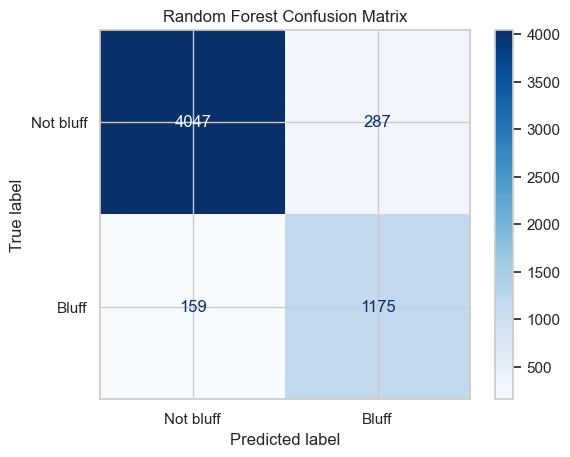

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=0)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n",
      classification_report(y_test, y_pred_rf, zero_division=0))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Not bluff", "Bluff"], cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

### Gradient Boosting

Gradient Boosting Accuracy: 0.9176076217360621

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95      4334
           1       0.79      0.88      0.83      1334

    accuracy                           0.92      5668
   macro avg       0.88      0.90      0.89      5668
weighted avg       0.92      0.92      0.92      5668


Gradient Boosting Confusion Matrix:
 [[4032  302]
 [ 165 1169]]


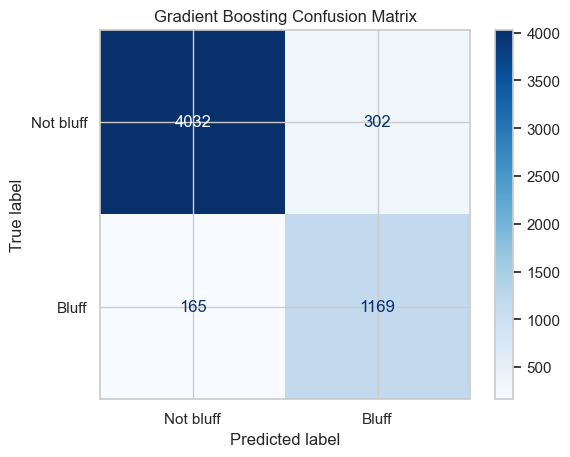

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=0)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nGradient Boosting Classification Report:\n",
      classification_report(y_test, y_pred_gb, zero_division=0))
print("\nGradient Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, display_labels=["Not bluff", "Bluff"], cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

U okviru eksperimenata testirana su četiri klasifikaciona modela: Logistic Regression, Naive Bayes, Random Forest i Gradient Boosting, sa ciljem predikcije jačine poker ruke na Riveru koristeći informacije nakon Flop i Turn faze.

Dobijeni rezultati pokazuju sledeće: Logistic Regression i Naive Bayes modeli postižu tačnost od oko 79–80%, dok Random Forest i Gradient Boosting ostvaruju znatno višu tačnost od preko 92%.

Kod Logistic Regression modela tačnost iznosi 0.80. Model postiže visoku preciznost za klasu 0 (preciznost 0.95), ali slabiju preciznost za klasu 1 (0.54), dok mu je odziv za klasu 1 dobar (0.88). Model retko pogrešno označava ruku kao “blef” (klasa 1), ali i dalje ima veliki broj lažnih negativnih i propušta deo pravih blef situacija.

Naive Bayes daje sličnu ukupnu tačnost (0.79), preciznost za negativnu klasu je i dalje visoka (0.91), ali je recall za blef (klasa 1) slabiji (0.73), što potvrđuje da je Naive Bayes generalno manje fleksibilan u izraženim nelinearnostima i korelacijama između ulaza.

Random Forest i Gradient Boosting značajno nadmašuju linearne modele, sa tačnošću od 0.92. Ovi modeli su ravnomerniji po pitanju preciznosti i odziva u obe klase: preciznost i recall za “blef” su oko 0.80 i 0.88 za Random Forest (i sl. za Gradient Boosting), što pokazuje bolji balans između pravih pozitivnih i pravih negativnih predikcija.

Informacije na flopu i turnu sadrže signal za razliku između klasa, ali nisu determinističke za konačan ishod, što uvodi određeni nivo neizvesnosti za sve modele. Linearni modeli (logistička regresija i Naive Bayes) ne uspevaju u potpunosti da iskoriste nelinearne zavisnosti, dok Random Forest i Gradient Boosting to bolje modeluju, objašnjavajući poboljšane rezultate.

Na osnovu svega navedenog, može se zaključiti da ansambl modeli (Random Forest, Gradient Boosting) predstavljaju optimalan izbor za ovaj problem, uzimajući u obzir dostupne podatke i karakter problema. Linearni modeli dostižu svoj maksimum i ne mogu dalje unaprediti performanse bez dodatka kvalitetnijih inputa ili više podataka.